# 🏆 Grouped LOO Z-Score Framework
## Grouped Leave-One-Out Player Influence Analysis — FIFA World Cup 2018 & 2022

### Methodology

Instead of traditional box-score scouting, this notebook evaluates players by
measuring how a team's **offensive structural efficiency** shifts when a
specific player is omitted from the system.

| Layer | Description |
|-------|-------------|
| **Target Metric** | Expected Goal Differential (xGD) via Possession Chain Value |
| **LOO Engine** | For every match, remove each player's involvement from possession chains that led to shots and measure the xGD drop |
| **Normalization** | All deltas normalized **per 90 minutes** using actual minutes played |
| **Peer Ranking** | Grouped Z-Scores within **6 different peer groupings** (positional cohorts, tiers, tenure, etc.) |
| **Source** | StatsBomb Open Data via `statsbombpy` |

### Why Possession Chain LOO?

A midfielder who completes three passes in a chain that leads to a 0.5 xG shot
gets credited with the **full chain value** — not just the final assist. Removing
*any* player from a chain breaks it, so every contributor shares the system
credit. The sum of all LOO deltas intentionally **exceeds** team xG — this
measures *system dependence*, not individual credit allocation.


In [1]:
# ── Imports & Configuration ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
from statsbombpy import sb
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 28)

# ── Tournament Registry ──────────────────────────────────────────────────
TOURNAMENTS = [
    {"competition_id": 43, "season_id": 3,   "label": "WC 2018"},
    {"competition_id": 43, "season_id": 106, "label": "WC 2022"},
]

MIN_MINUTES = 5          # Minimum on-field minutes to include a player-match
MIN_TOURNEY_MINUTES = 90 # Minimum tournament-level minutes to rank
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# Columns retained from StatsBomb events (skips nested types for Parquet)
EVENT_COLS = [
    "id", "index", "match_id", "team", "team_id",
    "player", "player_id", "position",
    "type", "minute", "second", "period", "duration",
    "possession", "possession_team", "possession_team_id",
    "shot_statsbomb_xg", "shot_outcome", "shot_type",
    "shot_key_pass_id", "pass_assisted_shot_id",
    "pass_shot_assist", "pass_goal_assist",
    "tournament",
]

# ── Position → Group Mappings ────────────────────────────────────────────

# 4-Tier (coarsest)
POSITION_TO_TIER = {
    "Goalkeeper": "GK",
    "Right Back": "DEF", "Left Back": "DEF",
    "Center Back": "DEF", "Right Center Back": "DEF", "Left Center Back": "DEF",
    "Right Wing Back": "DEF", "Left Wing Back": "DEF",
    "Center Defensive Midfield": "MID",
    "Right Defensive Midfield": "MID", "Left Defensive Midfield": "MID",
    "Center Midfield": "MID", "Right Center Midfield": "MID", "Left Center Midfield": "MID",
    "Right Midfield": "MID", "Left Midfield": "MID",
    "Right Wing": "MID", "Left Wing": "MID",
    "Center Attacking Midfield": "MID",
    "Right Attacking Midfield": "MID", "Left Attacking Midfield": "MID",
    "Center Forward": "FWD", "Right Center Forward": "FWD",
    "Left Center Forward": "FWD", "Secondary Striker": "FWD",
}

# 7-Cohort (recommended)
POSITION_TO_COHORT = {
    "Goalkeeper": "Goalkeeper",
    "Center Back": "Center Back", "Right Center Back": "Center Back", "Left Center Back": "Center Back",
    "Right Back": "Fullback", "Left Back": "Fullback",
    "Right Wing Back": "Fullback", "Left Wing Back": "Fullback",
    "Center Defensive Midfield": "Defensive Mid",
    "Right Defensive Midfield": "Defensive Mid", "Left Defensive Midfield": "Defensive Mid",
    "Center Midfield": "Central Mid", "Right Center Midfield": "Central Mid", "Left Center Midfield": "Central Mid",
    "Center Attacking Midfield": "Central Mid",
    "Right Attacking Midfield": "Winger", "Left Attacking Midfield": "Winger",
    "Right Wing": "Winger", "Left Wing": "Winger",
    "Right Midfield": "Winger", "Left Midfield": "Winger",
    "Center Forward": "Forward", "Right Center Forward": "Forward",
    "Left Center Forward": "Forward", "Secondary Striker": "Forward",
}

print("✅ Configuration loaded")
print(f"   Tournaments : {[t['label'] for t in TOURNAMENTS]}")
print(f"   Min minutes : {MIN_MINUTES}")
print(f"   Data cache  : {DATA_DIR.resolve()}")

✅ Configuration loaded
   Tournaments : ['WC 2018', 'WC 2022']
   Min minutes : 5
   Data cache  : /Users/sam/Locals Only/World Cup z-Scores/data


---
## 1 · Data Ingestion & Pipeline Baseline

- **StatsBomb Open Data** — free, research-grade event data for FIFA World Cups.
- Events are loaded per match via `sb.events()`, lineups via `sb.lineups()`.
- Results are **cached to Parquet** so the API is only hit once (~3 min on first run).
- A **2026 CSV stub** is provided for manual data ingestion when StatsBomb releases live data.


In [2]:
# ── Ingestion Helpers ─────────────────────────────────────────────────────

def _ts_to_minutes(ts_str):
    """Parse a MM:SS timestamp (e.g. 86:31) to fractional minutes."""
    if ts_str is None:
        return 0.0
    parts = str(ts_str).split(":")
    if len(parts) >= 2:
        return int(parts[0]) + int(parts[1]) / 60
    return float(parts[0])


# ── Main Ingestion Pipeline ──────────────────────────────────────────────

def ingest_tournament_data(tournaments, data_dir):
    """
    Load StatsBomb events + player-minutes for every match in the registry.
    Also extracts on-field opponent xG conceded and defensive disruptions.
    First run hits the API (~3 min for 128 matches); subsequent runs use cache.
    """
    events_cache = data_dir / "events_raw.parquet"
    minutes_cache = data_dir / "player_minutes.parquet"

    if events_cache.exists() and minutes_cache.exists():
        print("📦 Loading from Parquet cache …")
        return pd.read_parquet(events_cache), pd.read_parquet(minutes_cache)

    all_events, all_minutes = [], []

    for t in tournaments:
        cid, sid, label = t["competition_id"], t["season_id"], t["label"]
        print(f"\n{chr(9472) * 60}")
        print(f"  Ingesting {label}  (comp={cid}, season={sid})")
        print(f"{chr(9472) * 60}")

        matches = sb.matches(competition_id=cid, season_id=sid)
        n = len(matches)

        for i, (_, m) in enumerate(matches.iterrows()):
            mid = m["match_id"]

            # Events
            ev = sb.events(match_id=mid)
            ev["tournament"] = label
            keep = [c for c in EVENT_COLS if c in ev.columns]
            all_events.append(ev[keep])

            # Opponent Shots
            shots = ev[ev["type"] == "Shot"].copy()
            shots["shot_statsbomb_xg"] = shots["shot_statsbomb_xg"].fillna(0)

            # Defensive Events
            defensive_events = ev[
                (ev["type"].isin(["Interception", "Block", "Clearance", "Ball Recovery"])) |
                ((ev["type"] == "Duel") & (ev["team"] != ev["possession_team"]))
            ].copy()

            match_max_min = ev["minute"].max()
            lu = sb.lineups(match_id=mid)

            # Parse lineups and calculate player-match statistics
            for team_name, roster in lu.items():
                opponent_team_name = [t for t in lu.keys() if t != team_name][0]
                opp_shots = shots[shots["team"] == opponent_team_name]

                for _, p in roster.iterrows():
                    positions = p.get("positions", [])
                    if not positions:
                        continue

                    total_minutes = 0.0
                    primary_pos = None
                    max_stint = 0.0
                    stints_intervals = []

                    for stint in positions:
                        from_min = _ts_to_minutes(stint.get("from", "0:00"))
                        to_val = stint.get("to")
                        to_min = match_max_min if to_val is None else _ts_to_minutes(to_val)
                        dur = max(0.0, to_min - from_min)
                        total_minutes += dur
                        stints_intervals.append((from_min, to_min))
                        if dur > max_stint:
                            max_stint = dur
                            primary_pos = stint.get("position")

                    if total_minutes > 0:
                        opp_xg_conceded = 0.0
                        for _, shot in opp_shots.iterrows():
                            shot_min = shot["minute"]
                            if any(from_m <= shot_min <= to_m for from_m, to_m in stints_intervals):
                                opp_xg_conceded += shot["shot_statsbomb_xg"]

                        p_def_events = defensive_events[defensive_events["player_id"] == p["player_id"]]
                        def_disruptions = len(p_def_events)

                        all_minutes.append({
                            "match_id": mid,
                            "team": team_name,
                            "tournament": label,
                            "player_id": p["player_id"],
                            "player": p["player_name"],
                            "minutes_played": round(total_minutes, 1),
                            "primary_position": primary_pos,
                            "opponent_xg_conceded": round(opp_xg_conceded, 4),
                            "defensive_disruptions": def_disruptions,
                        })

            if (i + 1) % 16 == 0 or (i + 1) == n:
                print(f"    {i + 1:>3}/{n} matches ...")

    events_df = pd.concat(all_events, ignore_index=True)
    minutes_df = pd.DataFrame(all_minutes)

    # Persist
    events_df.to_parquet(events_cache, index=False)
    minutes_df.to_parquet(minutes_cache, index=False)
    print(f"\n✅ Cached {len(events_df):,} events  &  {len(minutes_df):,} player-match rows")

    return events_df, minutes_df


In [3]:
# ── Execute Ingestion ─────────────────────────────────────────────────────

events_df, player_minutes_df = ingest_tournament_data(TOURNAMENTS, DATA_DIR)

# ── Sanity: 64 matches per tournament ────────────────────────────────────
for t in TOURNAMENTS:
    label = t["label"]
    n = events_df.loc[events_df["tournament"] == label, "match_id"].nunique()
    status = "✅" if n == 64 else "⚠️"
    print(f"  {status} {label}: {n} matches")

# ── Dataset summary as DataFrame ──────────────────────────────────────────
summary_df = pd.DataFrame({
    "Metric": [
        "Total events",
        "Player-match records",
        "Unique matches",
        "Unique players",
        "Tournaments",
        "Opponent xG Conceded",
        "Defensive Disruptions"
    ],
    "Value": [
        f"{len(events_df):,}",
        f"{len(player_minutes_df):,}",
        f"{events_df['match_id'].nunique():,}",
        f"{player_minutes_df['player_id'].nunique():,}",
        ", ".join(events_df['tournament'].unique().tolist()),
        f"{player_minutes_df['opponent_xg_conceded'].sum():.1f}",
        f"{player_minutes_df['defensive_disruptions'].sum():,}"
    ]
})
summary_df

📦 Loading from Parquet cache …
  ✅ WC 2018: 64 matches
  ✅ WC 2022: 64 matches


,Metric,Value
0,Total events,"462,462"
1,Player-match records,"3,785"
2,Unique matches,128
3,Unique players,"1,092"
4,Tournaments,"WC 2018, WC 2022"
5,Opponent xG Conceded,4351.3
6,Defensive Disruptions,"27,507"


---
## 2 · Feature Engineering: Team Match xG & xGD

For each `(match_id, team)` pair we compute:

| Metric | Formula |
|--------|---------|
| `team_xg` | Σ `shot_statsbomb_xg` for all shots by the team |
| `opponent_xg` | The opposing team's `team_xg` in the same match |
| `team_xgd` | `team_xg − opponent_xg` |
| `match_max_minute` | Max event minute in the match (accounts for stoppage time) |


In [4]:
# ── Team-Match xG & xGD ───────────────────────────────────────────────────

def build_team_match_xg(events_df):
    """
    Aggregate shot-level xG into team-match summaries.
    Handles the edge case of teams with 0 shots via a left join.
    """
    # Every unique (match, team, tournament) -- guarantees 0-shot teams appear
    match_teams = (
        events_df[["match_id", "team", "tournament"]]
        .drop_duplicates()
    )

    # Shot-level aggregation
    shots = events_df[events_df["type"] == "Shot"].copy()
    shots["shot_statsbomb_xg"] = shots["shot_statsbomb_xg"].fillna(0)

    team_xg = (
        shots
        .groupby(["match_id", "team"])["shot_statsbomb_xg"]
        .sum()
        .reset_index()
        .rename(columns={"shot_statsbomb_xg": "team_xg"})
    )

    # Left join to preserve 0-shot teams
    result = match_teams.merge(team_xg, on=["match_id", "team"], how="left")
    result["team_xg"] = result["team_xg"].fillna(0)

    # Opponent xG via self-join
    opp = result[["match_id", "team", "team_xg"]].rename(
        columns={"team": "opponent", "team_xg": "opponent_xg"}
    )
    result = result.merge(opp, on="match_id")
    result = result[result["team"] != result["opponent"]].drop(columns=["opponent"])

    # xGD
    result["team_xgd"] = result["team_xg"] - result["opponent_xg"]

    # Match duration from max event minute
    match_dur = (
        events_df
        .groupby("match_id")["minute"]
        .max()
        .reset_index()
        .rename(columns={"minute": "match_max_minute"})
    )
    result = result.merge(match_dur, on="match_id")

    return result


team_match_xg = build_team_match_xg(events_df)

# ── Sanity checks ────────────────────────────────────────────────────────
print(f"Team-match records: {len(team_match_xg)} (expected: {events_df['match_id'].nunique() * 2})")

# Describe both side-by-side as a single DataFrame
pd.DataFrame({
    "team_xg": team_match_xg["team_xg"].describe(),
    "team_xgd": team_match_xg["team_xgd"].describe()
}).round(3)

Team-match records: 256 (expected: 256)


,team_xg,team_xgd
count,256.000,256.000
mean,1.529,0.000
std,1.232,1.314
min,0.000,-4.148
25%,0.697,-0.796
50%,1.184,0.000
75%,1.890,0.796
max,6.162,4.148


---
## 3 · Leave-One-Out (LOO) Engine

### Possession Chain LOO — how it works

For each match we:
1. **Identify valuable chains** — possession sequences (StatsBomb `possession` ID) that end in at least one shot.
2. **Value each chain** — `chain_xg = Σ shot_statsbomb_xg` for all shots in that chain.
3. **Credit every participant** — any player from the possession team who had an event in that chain is considered a contributor.
4. **LOO Influence Δ** — player's total = Σ `chain_xg` across all chains they participated in.

**Key property**: since multiple players share credit for the same chain, the sum of LOO deltas across a team's roster will **exceed** the team's raw xG. This is by design — it quantifies *system dependence*.


In [5]:
# ── LOO Engine ────────────────────────────────────────────────────────────

def compute_loo_influence(events_df, player_minutes_df, team_match_xg):
    """
    Possession-chain-based Leave-One-Out engine.
    Returns a per-match, per-player DataFrame with offensive & defensive metrics.
    """
    # Group all events by possession chain to calculate stats for every chain
    shots = events_df[events_df["type"] == "Shot"].copy()
    shots["shot_statsbomb_xg"] = shots["shot_statsbomb_xg"].fillna(0)
    
    # xG sum per chain
    chain_xg_sum = (
        shots
        .groupby(["match_id", "possession"])["shot_statsbomb_xg"]
        .sum()
        .reset_index()
    )
    
    # Event count per chain
    chain_events_count = (
        events_df
        .groupby(["match_id", "possession"])["id"]
        .count()
        .reset_index()
        .rename(columns={"id": "event_count"})
    )
    
    # Base chain info (possession_team)
    chain_team = (
        events_df[["match_id", "possession", "possession_team"]]
        .drop_duplicates()
    )
    
    # Merge chain stats
    chain_stats = chain_team.merge(chain_xg_sum, on=["match_id", "possession"], how="left")
    chain_stats["shot_statsbomb_xg"] = chain_stats["shot_statsbomb_xg"].fillna(0)
    chain_stats = chain_stats.rename(columns={"shot_statsbomb_xg": "chain_xg"})
    
    chain_stats = chain_stats.merge(chain_events_count, on=["match_id", "possession"], how="left")
    chain_stats["event_count"] = chain_stats["event_count"].fillna(0)
    
    # PCV (Possession Chain Value): chain_xg + 0.01 * event_count
    chain_stats["chain_pcv"] = chain_stats["chain_xg"] + 0.01 * chain_stats["event_count"]
    
    print(f"Total possession chains: {len(chain_stats):,}")
    print(f"Valuable chains (end in shot): {len(chain_stats[chain_stats['chain_xg'] > 0]):,}")

    # Step 2: identify offensive and defensive participants in each chain
    # Inner join events with chain_stats to map chain metrics back to events
    chain_events = events_df.merge(
        chain_stats[["match_id", "possession", "chain_xg", "chain_pcv"]],
        on=["match_id", "possession"],
        how="inner",
    )
    
    # 2.1 Offensive involvement (possession team players)
    off_events = chain_events[
        (chain_events["team"] == chain_events["possession_team"]) &
        (chain_events["player_id"].notna())
    ]
    player_off_chains = off_events[["match_id", "possession", "team", "player_id"]].drop_duplicates()
    player_off_chains = player_off_chains.merge(
        chain_stats[["match_id", "possession", "chain_xg", "chain_pcv"]],
        on=["match_id", "possession"],
        how="inner"
    )
    player_off_metrics = (
        player_off_chains
        .groupby(["match_id", "team", "player_id"]).agg(
            influence_delta_off_xg=("chain_xg", "sum"),
            influence_delta_off_pcv=("chain_pcv", "sum")
        )
        .reset_index()
    )
    
    # 2.2 Defensive chain disruptions (interceptions, tackles, blocks, clearances, ball recoveries, duels during opponent possession)
    def_disrupt_types = ["Interception", "Block", "Clearance", "Ball Recovery", "Duel"]
    def_events = chain_events[
        (chain_events["team"] != chain_events["possession_team"]) &
        (chain_events["player_id"].notna()) &
        (chain_events["type"].isin(def_disrupt_types))
    ]
    player_def_chains = def_events[["match_id", "possession", "team", "player_id"]].drop_duplicates()
    player_def_chains = player_def_chains.merge(
        chain_stats[["match_id", "possession", "chain_xg", "chain_pcv"]],
        on=["match_id", "possession"],
        how="inner"
    )
    player_def_metrics = (
        player_def_chains
        .groupby(["match_id", "team", "player_id"]).agg(
            influence_delta_def_xg=("chain_xg", "sum"),
            influence_delta_def_pcv=("chain_pcv", "sum")
        )
        .reset_index()
    )

    # Step 3: merge with player minutes & normalize per 90
    pm = player_minutes_df[player_minutes_df["minutes_played"] >= MIN_MINUTES].copy()

    result = pm.merge(
        player_off_metrics,
        on=["match_id", "team", "player_id"],
        how="left",
    )
    result = result.merge(
        player_def_metrics,
        on=["match_id", "team", "player_id"],
        how="left",
    )
    
    # Fill NaNs with 0
    cols_to_fill = [
        "influence_delta_off_xg", "influence_delta_off_pcv",
        "influence_delta_def_xg", "influence_delta_def_pcv"
    ]
    for c in cols_to_fill:
        result[c] = result[c].fillna(0)
        
    # Net Deltas
    result["influence_delta"] = result["influence_delta_off_xg"]
    result["influence_delta_net_xg"] = result["influence_delta_off_xg"] - result["influence_delta_def_xg"]
    result["influence_delta_net_pcv"] = result["influence_delta_off_pcv"] - result["influence_delta_def_pcv"]

    # Per-90 normalization for all metrics
    result["influence_delta_p90"] = (
        result["influence_delta_off_xg"] / result["minutes_played"] * 90
    )
    result["influence_delta_off_xg_p90"] = result["influence_delta_p90"]
    result["influence_delta_def_xg_p90"] = (
        result["influence_delta_def_xg"] / result["minutes_played"] * 90
    )
    result["influence_delta_net_xg_p90"] = (
        result["influence_delta_net_xg"] / result["minutes_played"] * 90
    )
    
    result["influence_delta_off_pcv_p90"] = (
        result["influence_delta_off_pcv"] / result["minutes_played"] * 90
    )
    result["influence_delta_def_pcv_p90"] = (
        result["influence_delta_def_pcv"] / result["minutes_played"] * 90
    )
    result["influence_delta_net_pcv_p90"] = (
        result["influence_delta_net_pcv"] / result["minutes_played"] * 90
    )
    
    result["opponent_xg_p90"] = (
        result["opponent_xg_conceded"] / result["minutes_played"] * 90
    )
    result["disruptions_p90"] = (
        result["defensive_disruptions"] / result["minutes_played"] * 90
    )

    # Attach team-level context
    result = result.merge(
        team_match_xg[["match_id", "team", "team_xg", "opponent_xg", "team_xgd"]],
        on=["match_id", "team"],
        how="left",
    )

    return result


In [6]:
# ── Run LOO Engine ────────────────────────────────────────────────────────

loo_match = compute_loo_influence(events_df, player_minutes_df, team_match_xg)

print(f"LOO match-level records: {len(loo_match):,}")

# Describe all three metrics side-by-side as a single DataFrame
pd.DataFrame({
    "influence_delta_p90": loo_match["influence_delta_p90"].describe(),
    "opponent_xg_p90": loo_match["opponent_xg_p90"].describe(),
    "disruptions_p90": loo_match["disruptions_p90"].describe()
}).round(4)

Total possession chains: 22,320
Valuable chains (end in shot): 2,905
LOO match-level records: 3,751


,influence_delta_p90,opponent_xg_p90,disruptions_p90
count,3751.0000,3751.0000,3751.0000
mean,0.5891,1.5132,8.9206
std,0.8167,2.2503,5.4417
min,0.0000,0.0000,0.0000
25%,0.1226,0.5432,5.2941
50%,0.3567,1.0556,8.4375
75%,0.7647,1.7941,11.9495
max,12.8209,41.9727,55.6701


---
## 4 · Tournament Aggregation & Multi-Group Assignment

Before computing Z-Scores we need two things:

1. **Tournament-level aggregation** — sum each player's raw influence and minutes across all matches in a tournament, then re-derive per-90.
2. **Group assignment** — assign every player to all 6 peer groupings based on their **tournament-level primary position** (the position they played the most total minutes in across the tournament).

### The 6 Grouping Strategies

| # | Key | Cohorts | Purpose |
|---|-----|---------|---------|
| 1 | `group_global` | 1 | Baseline — un-grouped |
| 2 | `group_tier` | 4 (GK/DEF/MID/FWD) | Coarse positional |
| 3 | `group_cohort` | 7 | Recommended granularity |
| 4 | `group_position_raw` | 18 | Fine-grained StatsBomb |
| 5 | `group_tenure` | 2 (First WC / Returning) | Cross-tournament experience |
| 6 | `group_age` | 3 (Young/Prime/Veteran) | Requires supplemental CSV |


In [7]:
# ── Tournament-Level Aggregation ──────────────────────────────────────────

loo_tournament = (
    loo_match
    .groupby(["player_id", "player", "team", "tournament"])
    .agg(
        minutes_played=("minutes_played", "sum"),
        influence_delta=("influence_delta", "sum"),
        opponent_xg_conceded=("opponent_xg_conceded", "sum"),
        defensive_disruptions=("defensive_disruptions", "sum"),
        team_xg_total=("team_xg", "sum"),
        opponent_xg_total=("opponent_xg", "sum"),
        team_xgd_total=("team_xgd", "sum"),
        matches_played=("match_id", "count"),
        
        # New LOO aggregations
        influence_delta_off_xg=("influence_delta_off_xg", "sum"),
        influence_delta_def_xg=("influence_delta_def_xg", "sum"),
        influence_delta_net_xg=("influence_delta_net_xg", "sum"),
        influence_delta_off_pcv=("influence_delta_off_pcv", "sum"),
        influence_delta_def_pcv=("influence_delta_def_pcv", "sum"),
        influence_delta_net_pcv=("influence_delta_net_pcv", "sum"),
    )
    .reset_index()
)

# Filter by minimum tournament-level minutes
loo_tournament = loo_tournament[loo_tournament["minutes_played"] >= MIN_TOURNEY_MINUTES]

# Recalculate per-90 metrics from tournament totals
loo_tournament["influence_delta_p90"] = (
    loo_tournament["influence_delta"] / loo_tournament["minutes_played"] * 90
)
loo_tournament["influence_delta_off_xg_p90"] = loo_tournament["influence_delta_p90"]
loo_tournament["influence_delta_def_xg_p90"] = (
    loo_tournament["influence_delta_def_xg"] / loo_tournament["minutes_played"] * 90
)
loo_tournament["influence_delta_net_xg_p90"] = (
    loo_tournament["influence_delta_net_xg"] / loo_tournament["minutes_played"] * 90
)

loo_tournament["influence_delta_off_pcv_p90"] = (
    loo_tournament["influence_delta_off_pcv"] / loo_tournament["minutes_played"] * 90
)
loo_tournament["influence_delta_def_pcv_p90"] = (
    loo_tournament["influence_delta_def_pcv"] / loo_tournament["minutes_played"] * 90
)
loo_tournament["influence_delta_net_pcv_p90"] = (
    loo_tournament["influence_delta_net_pcv"] / loo_tournament["minutes_played"] * 90
)

loo_tournament["opponent_xg_p90"] = (
    loo_tournament["opponent_xg_conceded"] / loo_tournament["minutes_played"] * 90
)
loo_tournament["disruptions_p90"] = (
    loo_tournament["defensive_disruptions"] / loo_tournament["minutes_played"] * 90
)

# ── Tournament-Level Primary Position ────────────────────────────────────
pos_minutes = (
    loo_match
    .groupby(["player_id", "tournament", "primary_position"])["minutes_played"]
    .sum()
    .reset_index()
    .rename(columns={"minutes_played": "pos_total_minutes"})
)

idx = pos_minutes.groupby(["player_id", "tournament"])["pos_total_minutes"].idxmax()
tourney_pos = (
    pos_minutes.loc[idx, ["player_id", "tournament", "primary_position"]]
    .rename(columns={"primary_position": "tournament_position"})
    .reset_index(drop=True)
)

loo_tournament = loo_tournament.merge(tourney_pos, on=["player_id", "tournament"])

# ── Assign All 6 Group Columns ───────────────────────────────────────────
loo_tournament["group_global"] = "All Players"
loo_tournament["group_tier"] = loo_tournament["tournament_position"].map(POSITION_TO_TIER)
loo_tournament["group_cohort"] = loo_tournament["tournament_position"].map(POSITION_TO_COHORT)
loo_tournament["group_position_raw"] = loo_tournament["tournament_position"]

player_tourney_ct = (
    loo_tournament
    .groupby("player_id")["tournament"]
    .nunique()
    .reset_index()
    .rename(columns={"tournament": "n_tournaments"})
)
loo_tournament = loo_tournament.merge(player_tourney_ct, on="player_id")
loo_tournament["group_tenure"] = loo_tournament["n_tournaments"].apply(
    lambda n: "Returning" if n > 1 else "First WC"
)
loo_tournament.drop(columns=["n_tournaments"], inplace=True)

loo_tournament["group_age"] = "Unknown"

print(f"\nTournament-level player records: {len(loo_tournament):,}")



Tournament-level player records: 978


---
## 5 · Grouped Peer Standardization (Z-Scores)

For each of the 6 grouping strategies:

$$Z_i = \frac{x_i - \mu_g}{\sigma_g}$$

where $\mu_g$ and $\sigma_g$ are the mean and standard deviation of the per-90 LOO Influence Delta **within group $g$**.

### Small-Sample Safeguard

If a positional cohort has fewer than 10 players, its $\sigma$ is replaced with
a **pooled $\sigma$** (size-weighted average across all cohorts). This prevents
extreme Z-Scores from tiny, low-variance groups — a common trap in grouped
standardization with rare positions like Defensive Midfielders.


In [8]:
# ── Generic Grouped Z/T Score Engine ──────────────────────────────────────

def compute_grouped_scores(df, value_col, group_col, min_cohort_size=10, invert=False):
    """
    Compute Z-Scores within each peer group.
    If invert=True, lower values of value_col will yield higher Z-scores.
    """
    z_col = f"{group_col}_{value_col.replace("_p90", "")}_zscore"

    result = df.copy()
    result[z_col] = np.nan

    # Per-group statistics
    gstats = (
        df.groupby(group_col, observed=True)[value_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # Pooled sigma for small-sample fallback
    valid = gstats.dropna(subset=["std"])
    if len(valid) > 0 and valid["count"].sum() > 0:
        pooled_std = (
            (valid["std"] * valid["count"]).sum() / valid["count"].sum()
        )
    else:
        pooled_std = 1.0

    if pooled_std == 0:
        pooled_std = 1.0

    for _, gs in gstats.iterrows():
        grp = gs[group_col]
        mu = gs["mean"]
        sigma = gs["std"]
        n = gs["count"]

        if n < min_cohort_size or pd.isna(sigma) or sigma == 0:
            sigma = pooled_std

        mask = result[group_col] == grp
        val_slice = result.loc[mask, value_col]
        
        if invert:
            z = (mu - val_slice) / sigma
        else:
            z = (val_slice - mu) / sigma
            
        result.loc[mask, z_col] = z

    return result


In [9]:
# ── Apply Z-Scores Across All Metrics & Grouping Strategies ──────────────

GROUP_COLS = ["group_global", "group_tier", "group_cohort", "group_position_raw"]

# Weight mapping dictionary based on 7-cohort primary positions
COHORT_WEIGHTS = {
    "Forward":    {"off": 0.70, "conceded": 0.15, "disrupt": 0.15},
    "Winger":     {"off": 0.70, "conceded": 0.15, "disrupt": 0.15},
    "Central Mid":{"off": 0.40, "conceded": 0.30, "disrupt": 0.30},
    "Defensive Mid":{"off": 0.40, "conceded": 0.30, "disrupt": 0.30},
    "Fullback":   {"off": 0.15, "conceded": 0.45, "disrupt": 0.40},
    "Center Back": {"off": 0.15, "conceded": 0.45, "disrupt": 0.40},
    "Goalkeeper":  {"off": 0.00, "conceded": 1.00, "disrupt": 0.00},
}

scored = loo_tournament.copy()

# Standardize all sub-metrics under every grouping strategy
for gc in GROUP_COLS:
    # Original metrics for compatibility
    scored = compute_grouped_scores(scored, "influence_delta_p90", gc, invert=False)
    scored = compute_grouped_scores(scored, "opponent_xg_p90", gc, invert=True)
    scored = compute_grouped_scores(scored, "disruptions_p90", gc, invert=False)
    
    # New xGD LOO metrics
    scored = compute_grouped_scores(scored, "influence_delta_off_xg_p90", gc, invert=False)
    scored = compute_grouped_scores(scored, "influence_delta_def_xg_p90", gc, invert=False)
    scored = compute_grouped_scores(scored, "influence_delta_net_xg_p90", gc, invert=False)
    
    # New PCV LOO metrics
    scored = compute_grouped_scores(scored, "influence_delta_off_pcv_p90", gc, invert=False)
    scored = compute_grouped_scores(scored, "influence_delta_def_pcv_p90", gc, invert=False)
    scored = compute_grouped_scores(scored, "influence_delta_net_pcv_p90", gc, invert=False)


---
### 💡 Concept Spotlight: Peer Group Standardization Sensitivity

To understand why standardizing within peer groups is necessary, let's look at **Marcelo** (Brazil's left fullback at Russia 2018). Marcelo is renowned for his elite offensive contributions, but how does his Offensive Influence Delta (shot involvement value) rank depending on who he is compared to?


Player: Marcelo Vieira da Silva Júnior (Brazil) - WC 2018
Raw Offensive Influence Delta/90: 1.28

  Peer Grouping Strategy Peer Group Name  Offensive Z-Score
    Global (All Players)     All Players               1.83
        Tier (Defenders)             DEF               2.58
      Cohort (Fullbacks)        Fullback               2.47
Raw Position (Left Back)       Left Back               2.71

Interpretation:
- Compared globally (against all players), Marcelo is already very strong (+1.83).
- Compared strictly against other defenders or fullbacks, his rating rises to elite levels (+2.47 to +2.71),
  showing that he is over 2.5 standard deviations above the average player in his position.


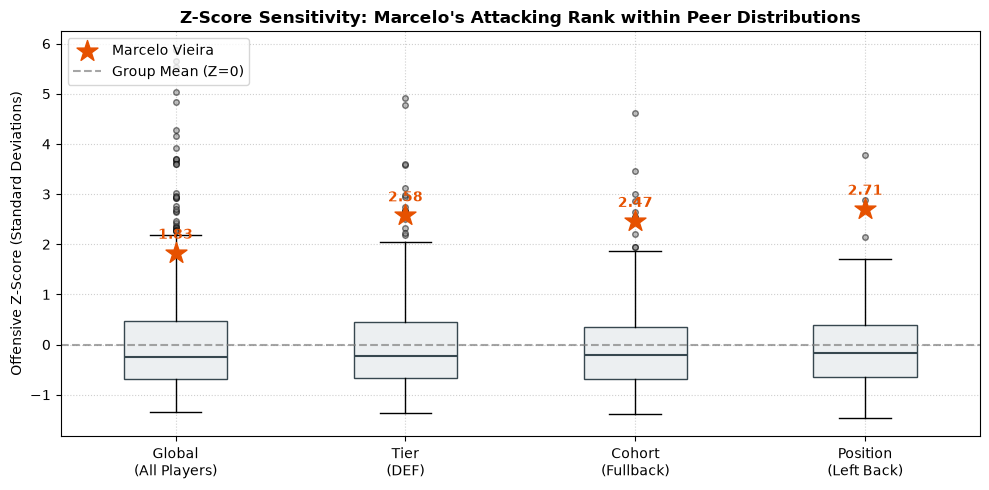

In [10]:
# ── Peer Group Sensitivity Example & Plot ────────────────────────────────

import matplotlib.pyplot as plt

# Spotlight Marcelo (Left Back for Brazil in WC 2018)
marcelo = scored[(scored["player"].str.contains("Vieira")) & (scored["tournament"] == "WC 2018")].iloc[0]

comparison = pd.DataFrame({
    "Peer Grouping Strategy": [
        "Global (All Players)",
        "Tier (Defenders)",
        "Cohort (Fullbacks)",
        "Raw Position (Left Back)"
    ],
    "Peer Group Name": [
        marcelo["group_global"],
        marcelo["group_tier"],
        marcelo["group_cohort"],
        marcelo["group_position_raw"]
    ],
    "Offensive Z-Score": [
        marcelo["group_global_influence_delta_zscore"],
        marcelo["group_tier_influence_delta_zscore"],
        marcelo["group_cohort_influence_delta_zscore"],
        marcelo["group_position_raw_influence_delta_zscore"]
    ]
})

print(f"Player: {marcelo['player']} ({marcelo['team']}) - {marcelo['tournament']}")
print(f"Raw Offensive Influence Delta/90: {marcelo['influence_delta_p90']:.2f}\n")
print(comparison.round(2).to_string(index=False))
print("\nInterpretation:")
print("- Compared globally (against all players), Marcelo is already very strong (+1.83).")
print("- Compared strictly against other defenders or fullbacks, his rating rises to elite levels (+2.47 to +2.71),")
print("  showing that he is over 2.5 standard deviations above the average player in his position.")

# Plot the sensitivity boxplot with Marcelo highlighted
# Get peer distributions
global_dist = scored["group_global_influence_delta_zscore"].dropna()
tier_dist = scored[scored["group_tier"] == marcelo["group_tier"]]["group_tier_influence_delta_zscore"].dropna()
cohort_dist = scored[scored["group_cohort"] == marcelo["group_cohort"]]["group_cohort_influence_delta_zscore"].dropna()
position_dist = scored[scored["group_position_raw"] == marcelo["group_position_raw"]]["group_position_raw_influence_delta_zscore"].dropna()

data_to_plot = [global_dist, tier_dist, cohort_dist, position_dist]

fig, ax = plt.subplots(figsize=(10, 5))

# Draw boxplots
box = ax.boxplot(
    data_to_plot, 
    tick_labels=[
        f"Global\n({marcelo['group_global']})", 
        f"Tier\n({marcelo['group_tier']})", 
        f"Cohort\n({marcelo['group_cohort']})", 
        f"Position\n({marcelo['group_position_raw']})"
    ],
    patch_artist=True,
    boxprops=dict(facecolor="#ECEFF1", color="#37474F"),
    medianprops=dict(color="#37474F", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=4, alpha=0.5)
)

# Highlight Marcelo's Z-scores as large orange stars
marcelo_z = [
    marcelo["group_global_influence_delta_zscore"],
    marcelo["group_tier_influence_delta_zscore"],
    marcelo["group_cohort_influence_delta_zscore"],
    marcelo["group_position_raw_influence_delta_zscore"]
]
x_coords = [1, 2, 3, 4]
ax.scatter(
    x_coords, 
    marcelo_z, 
    color="#E65100", 
    marker="*", 
    s=250, 
    zorder=5, 
    label="Marcelo Vieira"
)

# Annotate values
for x, val in zip(x_coords, marcelo_z):
    ax.annotate(
        f"{val:.2f}",
        (x, val),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        color="#E65100",
        weight="bold"
    )

ax.axhline(0, color="gray", linestyle="--", alpha=0.7, label="Group Mean (Z=0)")
ax.set_title("Z-Score Sensitivity: Marcelo's Attacking Rank within Peer Distributions", fontsize=12, weight="bold")
ax.set_ylabel("Offensive Z-Score (Standard Deviations)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [11]:
# ── Calculate Position-Weighted Composite Z-Scores ───────────────────────
# We will compute composite ratings for the recommended `group_cohort` grouping
composite_z = []
composite_z_xg = []
composite_z_pcv = []

for _, row in scored.iterrows():
    cohort = row["group_cohort"]
    w = COHORT_WEIGHTS.get(cohort, {"off": 0.33, "conceded": 0.33, "disrupt": 0.34})
    
    # 1. Original model
    z_off = row["group_cohort_influence_delta_zscore"]
    z_conceded = row["group_cohort_opponent_xg_zscore"]
    z_disrupt = row["group_cohort_disruptions_zscore"]
    z_comp = (w["off"] * z_off) + (w["conceded"] * z_conceded) + (w["disrupt"] * z_disrupt)
    composite_z.append(z_comp)
    
    # 2. xGD LOO model (player-specific defensive chain LOO)
    z_off_xg = row["group_cohort_influence_delta_off_xg_zscore"]
    z_def_xg = row["group_cohort_influence_delta_def_xg_zscore"]
    z_comp_xg = (w["off"] * z_off_xg) + (w["conceded"] * z_def_xg) + (w["disrupt"] * z_disrupt)
    composite_z_xg.append(z_comp_xg)
    
    # 3. PCV LOO model (Possession Chain Value LOO)
    z_off_pcv = row["group_cohort_influence_delta_off_pcv_zscore"]
    z_def_pcv = row["group_cohort_influence_delta_def_pcv_zscore"]
    z_comp_pcv = (w["off"] * z_off_pcv) + (w["conceded"] * z_def_pcv) + (w["disrupt"] * z_disrupt)
    composite_z_pcv.append(z_comp_pcv)

scored["composite_zscore"] = composite_z
scored["composite_zscore_xg"] = composite_z_xg
scored["composite_zscore_pcv"] = composite_z_pcv

# Sort by our new xGD LOO composite score by default
scored = scored.sort_values("composite_zscore_xg", ascending=False)
print("✅ Calculated all sub-metrics and position-weighted Composite Z-Scores!")


✅ Calculated all sub-metrics and position-weighted Composite Z-Scores!


In [12]:
# ── Rankings Table: Model Comparisons (Top 25 Players) ──────────────────

# Display Top 25 for all three models
display_cols_base = ["player", "team", "tournament", "tournament_position", "minutes_played"]

print(f"\n{'=' * 125}")
print("  TOP 25 PLAYERS BY ORIGINAL MODEL (uses team-level opponent xG conceded)")
print(f"{'=' * 125}")
original_top = scored.sort_values("composite_zscore", ascending=False)
print(original_top[display_cols_base + ["composite_zscore"]].head(25).round(2).to_string(index=False))

print(f"\n{'=' * 125}")
print("  TOP 25 PLAYERS BY xGD LOO MODEL (uses player-specific defensive chain LOO xG)")
print(f"{'=' * 125}")
xg_top = scored.sort_values("composite_zscore_xg", ascending=False)
print(xg_top[display_cols_base + ["composite_zscore_xg"]].head(25).round(2).to_string(index=False))

print(f"\n{'=' * 125}")
print("  TOP 25 PLAYERS BY PCV LOO MODEL (uses Possession Chain Value LOO)")
print(f"{'=' * 125}")
pcv_top = scored.sort_values("composite_zscore_pcv", ascending=False)
print(pcv_top[display_cols_base + ["composite_zscore_pcv"]].head(25).round(2).to_string(index=False))



  TOP 25 PLAYERS BY ORIGINAL MODEL (uses team-level opponent xG conceded)
                                 player    team tournament       tournament_position  minutes_played  composite_zscore
    Roberto Firmino Barbosa de Oliveira  Brazil    WC 2018            Center Forward           108.3              3.57
                 Douglas Costa de Souza  Brazil    WC 2018                Right Wing            90.8              3.11
Giorgian Daniel De Arrascaeta Benedetti Uruguay    WC 2018                 Left Wing            90.1              3.07
                            Kai Havertz Germany    WC 2022            Center Forward           112.4              3.06
                        Niclas Füllkrug Germany    WC 2022      Right Center Forward            91.7              2.93
                             Leroy Sané Germany    WC 2022                Right Wing           126.0              2.54
                             Phil Foden England    WC 2022                 Left Wing        

In [13]:
# ── Spotlight Role-based Leaderboards: Model Comparisons ──────────────────

roles_to_check = ["Forward", "Central Mid", "Center Back"]

for role in roles_to_check:
    print(f"\n{'=' * 125}")
    print(f"  TOP 10 {role.upper()}S - MODEL COMPARISON")
    print(f"{'=' * 125}")
    
    role_df = scored[scored["group_cohort"] == role].copy()
    
    # Sort and pick top 10 for each model to show how they compare
    top_orig = role_df.sort_values("composite_zscore", ascending=False).head(10)[["player", "team", "composite_zscore"]].reset_index(drop=True)
    top_xg = role_df.sort_values("composite_zscore_xg", ascending=False).head(10)[["player", "team", "composite_zscore_xg"]].reset_index(drop=True)
    top_pcv = role_df.sort_values("composite_zscore_pcv", ascending=False).head(10)[["player", "team", "composite_zscore_pcv"]].reset_index(drop=True)
    
    comp_df = pd.DataFrame({
        "Orig Player": top_orig["player"],
        "Orig Z": top_orig["composite_zscore"],
        "xGD LOO Player": top_xg["player"],
        "xGD Z": top_xg["composite_zscore_xg"],
        "PCV LOO Player": top_pcv["player"],
        "PCV Z": top_pcv["composite_zscore_pcv"]
    })
    
    print(comp_df.round(2).to_string())



  TOP 10 FORWARDS - MODEL COMPARISON
                           Orig Player  Orig Z                       xGD LOO Player  xGD Z                       PCV LOO Player  PCV Z
0  Roberto Firmino Barbosa de Oliveira    3.57  Roberto Firmino Barbosa de Oliveira   3.22              Marco Asensio Willemsen   2.25
1                          Kai Havertz    3.06                          Kai Havertz   2.92                          Kai Havertz   1.94
2                      Niclas Füllkrug    2.93                      Niclas Füllkrug   2.71  Roberto Firmino Barbosa de Oliveira   1.89
3                Michy Batshuayi Tunga    1.79                Michy Batshuayi Tunga   1.67                 Diego da Silva Costa   1.54
4                   Mario Gómez García    1.24                   Mario Gómez García   1.20                     Leandro Trossard   1.41
5                 Diego da Silva Costa    1.08                         Wahbi Khazri   1.01                        Thomas Müller   1.36
6       Lionel An

---
## Interpretation: Why Positional Grouping Matters

### The Problem with Global Rankings

When all players are ranked on a single global Z-Score, **strikers dominate**.
Their direct involvement in shots means they accumulate higher raw Influence
Deltas, pushing defenders and midfielders down the rankings regardless of how
exceptional they were *within their role*.

### What Positional Cohort Grouping Fixes

By standardizing *within* positional peer groups, we ask a different question:

> **How exceptional is this player compared to others in the same role?**

- A **center back** with a modest 0.15 per-90 Influence Delta might rank poorly
  globally but score a Z-Score of 1.5+ within the Center Back cohort — revealing
  them as an elite possession-chain contributor for their position.
- A **striker** with a high raw delta but average performance *relative to other
  strikers* might see their Z-Score drop from 2.0+ (global) to 0.0 (cohort).

### Risers & Fallers

- **Risers** tend to be defenders and deep-lying midfielders whose contributions
  are undervalued by global rankings.
- **Fallers** tend to be forwards whose high raw output is *expected* for their
  position and thus doesn't register as exceptional within their cohort.

### Multi-Tier Flexibility

The 6 grouping strategies provide a spectrum of peer definitions. Coarser
groupings (4-tier) give broader comparisons, while the raw 18-position grouping
provides maximum peer specificity — at the cost of small sample sizes that
trigger the pooled-σ safeguard.


---
## 6 · Player Spotlight: Lionel Messi Trend Analysis

To demonstrate the utility of standardized multi-metric Z-scores, this section compares **Lionel Messi's** ratings between Russia 2018 (where he played as a Center Attacking Midfielder) and Qatar 2022 (where he played as a Right Center Forward).


,Tournament,Date,Opponent,Minutes,Offensive LOO Z-Score,Defensive LOO Z-Score,Defensive Disruptions Z-Score
0,WC 2018,2018-06-16,Iceland (2018),95.0,0.98,-0.42,-0.71
1,WC 2018,2018-06-21,Croatia (2018),94.0,0.31,0.48,-0.29
2,WC 2018,2018-06-26,Nigeria (2018),94.0,-0.00,-0.38,0.65
3,WC 2018,2018-06-30,France (2018),95.0,0.15,-0.01,1.07
4,WC 2022,2022-11-22,Saudi Arabia (2022),103.0,1.63,-0.38,-0.54
5,WC 2022,2022-11-26,Mexico (2022),96.0,-0.45,-0.38,-0.48
6,WC 2022,2022-11-30,Poland (2022),96.0,2.15,-0.38,-0.26
7,WC 2022,2022-12-03,Australia (2022),97.0,0.44,0.91,-0.28
8,WC 2022,2022-12-09,Netherlands (2022),173.5,0.76,-0.38,-0.75
9,WC 2022,2022-12-13,Croatia (2022),95.0,1.25,-0.38,0.41


,Tournament,Date,Opponent,Minutes,Offensive LOO Z-Score,Defensive LOO Z-Score,Defensive Disruptions Z-Score
0,WC 2018,2018-06-16,Iceland (2018),95.0,0.98,-0.42,-0.71
1,WC 2018,2018-06-21,Croatia (2018),94.0,0.31,0.48,-0.29
2,WC 2018,2018-06-26,Nigeria (2018),94.0,-0.00,-0.38,0.65
3,WC 2018,2018-06-30,France (2018),95.0,0.15,-0.01,1.07
4,WC 2022,2022-11-22,Saudi Arabia (2022),103.0,1.63,-0.38,-0.54
5,WC 2022,2022-11-26,Mexico (2022),96.0,-0.45,-0.38,-0.48
6,WC 2022,2022-11-30,Poland (2022),96.0,2.15,-0.38,-0.26
7,WC 2022,2022-12-03,Australia (2022),97.0,0.44,0.91,-0.28
8,WC 2022,2022-12-09,Netherlands (2022),173.5,0.76,-0.38,-0.75
9,WC 2022,2022-12-13,Croatia (2022),95.0,1.25,-0.38,0.41


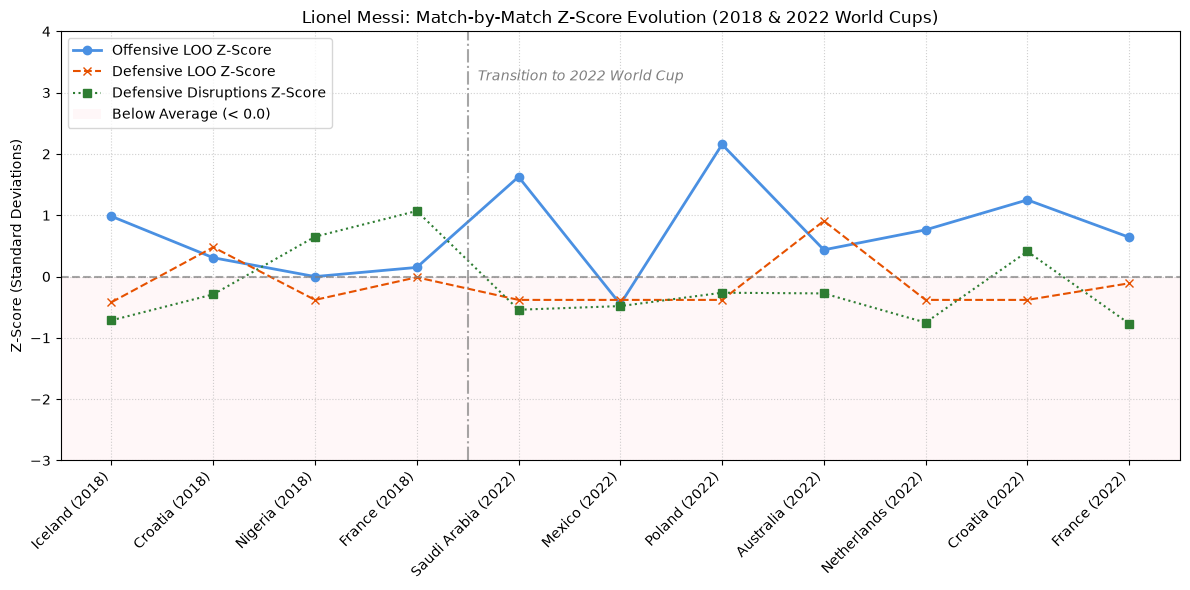

In [14]:
# ── Lionel Messi Spotlight & Trend Analysis ──────────────────────────────

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from statsbombpy import sb

# 1. Fetch match metadata (dates and opponents) to align chronologically
m18 = sb.matches(competition_id=43, season_id=3)[['match_id', 'match_date', 'kick_off', 'home_team', 'away_team']]
m22 = sb.matches(competition_id=43, season_id=106)[['match_id', 'match_date', 'kick_off', 'home_team', 'away_team']]
m_all = pd.concat([m18, m22], ignore_index=True)

# Calculate match-level Z-scores for all metrics including new v2 LOO ones
loo_match_z = loo_match.copy()
loo_match_z["group_cohort"] = loo_match_z["primary_position"].map(POSITION_TO_COHORT)
loo_match_z = compute_grouped_scores(loo_match_z, "influence_delta_off_xg_p90", "group_cohort", invert=False)
loo_match_z = compute_grouped_scores(loo_match_z, "influence_delta_def_xg_p90", "group_cohort", invert=False)
loo_match_z = compute_grouped_scores(loo_match_z, "influence_delta_net_xg_p90", "group_cohort", invert=False)
loo_match_z = compute_grouped_scores(loo_match_z, "influence_delta_off_pcv_p90", "group_cohort", invert=False)
loo_match_z = compute_grouped_scores(loo_match_z, "influence_delta_def_pcv_p90", "group_cohort", invert=False)
loo_match_z = compute_grouped_scores(loo_match_z, "influence_delta_net_pcv_p90", "group_cohort", invert=False)
loo_match_z = compute_grouped_scores(loo_match_z, "opponent_xg_p90", "group_cohort", invert=True)
loo_match_z = compute_grouped_scores(loo_match_z, "disruptions_p90", "group_cohort", invert=False)

# Filter Messi's match-level statistics
messi_match = loo_match_z[loo_match_z['player'].str.contains('Messi')].copy()
messi_match = messi_match.merge(m_all, on='match_id', how='left')
messi_match = messi_match.sort_values(['match_date', 'kick_off']).reset_index(drop=True)

# Derive opponent name for each match
opponents = []
for idx, row in messi_match.iterrows():
    opp_team = row['away_team'] if row['home_team'] == 'Argentina' else row['home_team']
    opponents.append(f"{opp_team} ({row['tournament'][-4:]})")
messi_match['Opponent'] = opponents

# 2. Display the DataFrame
messi_timeline = messi_match[[
    'tournament', 'match_date', 'Opponent', 'minutes_played', 
    'group_cohort_influence_delta_off_xg_zscore', 'group_cohort_influence_delta_def_xg_zscore', 'group_cohort_disruptions_zscore'
]].rename(columns={
    'tournament': 'Tournament',
    'match_date': 'Date',
    'minutes_played': 'Minutes',
    'group_cohort_influence_delta_off_xg_zscore': 'Offensive LOO Z-Score',
    'group_cohort_influence_delta_def_xg_zscore': 'Defensive LOO Z-Score',
    'group_cohort_disruptions_zscore': 'Defensive Disruptions Z-Score'
}).round(2)

display(HTML("<h3>🐐 Lionel Messi: Match-by-Match World Cup Z-Score Timeline</h3>"))
display(display(messi_timeline) or messi_timeline)

# 3. Plotting the chronological trend line
fig, ax1 = plt.subplots(figsize=(12, 6))

# Colors
color_off = '#4A90E2'
color_def = '#E65100'
color_dis = '#2E7D32'

line1 = ax1.plot(messi_match['Opponent'], messi_match['group_cohort_influence_delta_off_xg_zscore'], 
                 marker='o', linewidth=2, color=color_off, label='Offensive LOO Z-Score')
line2 = ax1.plot(messi_match['Opponent'], messi_match['group_cohort_influence_delta_def_xg_zscore'], 
                 marker='x', linestyle='--', linewidth=1.5, color=color_def, label='Defensive LOO Z-Score')
line3 = ax1.plot(messi_match['Opponent'], messi_match['group_cohort_disruptions_zscore'], 
                 marker='s', linestyle=':', linewidth=1.5, color=color_dis, label='Defensive Disruptions Z-Score')

ax1.axhline(0, color='gray', linestyle='--', alpha=0.7, label='Cohort Average (Z=0)')
# Shade below 0.0 to highlight below-average performances
ax1.axhspan(-3.0, 0.0, facecolor='#FFEBEE', alpha=0.4, label='Below Average Zone (< 0.0)')
ax1.set_ylabel('Z-Score (Standard Deviations)', color='black')
ax1.set_title("Lionel Messi: Match-by-Match Z-Score Evolution (2018 & 2022 World Cups)")
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticklabels(messi_match['Opponent'], rotation=45, ha='right')
ax1.set_ylim(-3.0, 4.0)
ax1.grid(True, linestyle=":", alpha=0.6)

# Combine legends
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines + [plt.Rectangle((0,0),1,1,fc='#FFEBEE',alpha=0.4)], labels + ['Below Average (< 0.0)'], loc='upper left')

# Highlight transition
ax1.axvline(x=3.5, color='gray', linestyle='-.', alpha=0.7)
ax1.text(3.6, 3.2, 'Transition to 2022 World Cup', color='gray', fontstyle='italic')

plt.tight_layout()
plt.show()


## 8. Cumulative Player Value Evolution: Tracking the World Cup Stars

To showcase individual contributions through the tournament, we evaluate individual stars in the **2022 World Cup**:
- **Lionel Messi (Argentina)**: Golden Ball winner, leading Argentina's attack.
- **Kylian Mbappé (France)**: Golden Boot winner, France's primary goal scorer.
- **Antoine Griezmann (France)**: The hybrid engine of France's midfield, evaluated highly by LOO metrics for his transitions and disruptions.

We plot:
1. **Lionel Messi’s Match-by-Match Breakdown** (Left): Showing his raw standardized Z-scores for offensive LOO, defensive LOO, and defensive disruptions. This highlights his offensive focus and pocket of defensive work against Australia.
2. **Cumulative Z-Score Comparison** (Right): The match-by-match cumulative sum of their composite Z-scores. The positive slopes and high terminal values (up to **+4.0 standard deviations** of value added) provide a highly intuitive representation of elite tournament performance.


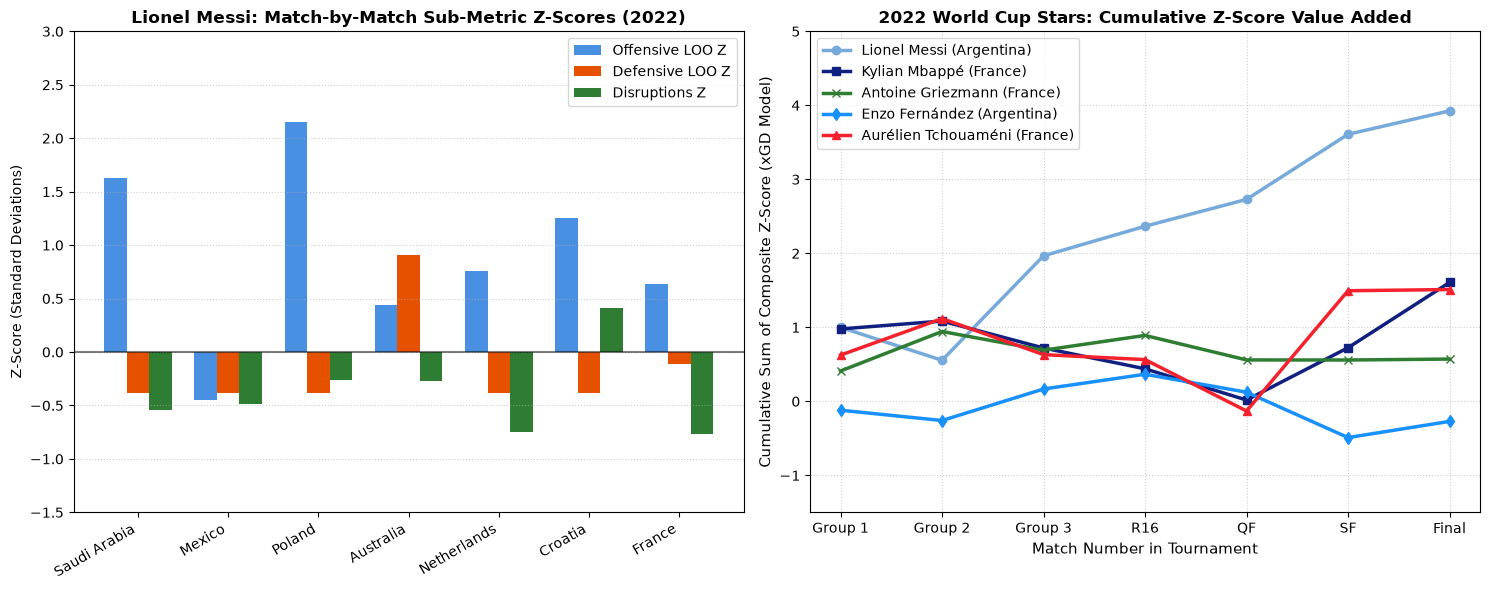

In [16]:
# ── Cumulative Player Value Evolution ──────────────────────────

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Define matches_meta self-contained
try:
    m18_meta = m18.copy()
    m22_meta = m22.copy()
except NameError:
    from statsbombpy import sb
    m18_meta = sb.matches(competition_id=43, season_id=3)[['match_id', 'match_date', 'kick_off', 'home_team', 'away_team']]
    m22_meta = sb.matches(competition_id=43, season_id=106)[['match_id', 'match_date', 'kick_off', 'home_team', 'away_team']]

m18_meta["tournament"] = "WC 2018"
m22_meta["tournament"] = "WC 2022"
m_all_meta = pd.concat([m18_meta, m22_meta], ignore_index=True)
matches_meta = m_all_meta.sort_values(["match_date", "kick_off"]).reset_index(drop=True)

# 2. Prepare data for finalists and stars
loo_match_z = loo_match.copy()
loo_match_z["group_cohort"] = loo_match_z["primary_position"].map(POSITION_TO_COHORT)

# Standardize match-level metrics (xGD LOO and disruptions)
loo_match_z = compute_grouped_scores(loo_match_z, "influence_delta_off_xg_p90", "group_cohort", invert=False)
loo_match_z = compute_grouped_scores(loo_match_z, "influence_delta_def_xg_p90", "group_cohort", invert=False)
loo_match_z = compute_grouped_scores(loo_match_z, "disruptions_p90", "group_cohort", invert=False)

comp_z_xg = []
for _, row in loo_match_z.iterrows():
    cohort = row["group_cohort"]
    w = COHORT_WEIGHTS.get(cohort, {"off": 0.33, "conceded": 0.33, "disrupt": 0.34})
    z_off_xg = row["group_cohort_influence_delta_off_xg_zscore"]
    z_def_xg = row["group_cohort_influence_delta_def_xg_zscore"]
    z_disrupt = row["group_cohort_disruptions_zscore"]
    comp_z_xg.append((w["off"] * z_off_xg) + (w["conceded"] * z_def_xg) + (w["disrupt"] * z_disrupt))
loo_match_z["composite_zscore_xg"] = comp_z_xg

# Join dates
player_match_z = loo_match_z.merge(
    matches_meta,
    on=["match_id", "tournament"],
    how="inner"
).sort_values(["match_date", "kick_off"])

def get_player_cumulative(player_name, tournament="WC 2022"):
    df = player_match_z[
        (player_match_z["player"].str.contains(player_name, case=False)) &
        (player_match_z["tournament"] == tournament)
    ].copy().sort_values(["match_date", "kick_off"])
    df["match_num"] = range(1, len(df) + 1)
    df["cumulative_z"] = df["composite_zscore_xg"].cumsum()
    return df

messi_22 = get_player_cumulative("Messi")
mbappe_22 = get_player_cumulative("Mbappé")
griezmann_22 = get_player_cumulative("Griezmann")
enzo_22 = get_player_cumulative("Enzo Fernandez")
tchouameni_22 = get_player_cumulative("Tchouaméni")

# 3. Plotting the dual-panel player value analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Messi's match-by-match Z-scores
opponents = ["Saudi Arabia", "Mexico", "Poland", "Australia", "Netherlands", "Croatia", "France"]
ax1.bar(np.arange(len(opponents)) - 0.25, messi_22["group_cohort_influence_delta_off_xg_zscore"], width=0.25, color='#4A90E2', label='Offensive LOO Z')
ax1.bar(np.arange(len(opponents)), messi_22["group_cohort_influence_delta_def_xg_zscore"], width=0.25, color='#E65100', label='Defensive LOO Z')
ax1.bar(np.arange(len(opponents)) + 0.25, messi_22["group_cohort_disruptions_zscore"], width=0.25, color='#2E7D32', label='Disruptions Z')

ax1.axhline(0, color='black', linestyle='-', alpha=0.5)
ax1.set_title("Lionel Messi: Match-by-Match Sub-Metric Z-Scores (2022)", fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(opponents)))
ax1.set_xticklabels(opponents, rotation=30, ha='right')
ax1.set_ylabel("Z-Score (Standard Deviations)")
ax1.grid(True, axis='y', linestyle=':', alpha=0.6)
ax1.legend()
ax1.set_ylim(-1.5, 3.0)

# Right plot: Cumulative Z-Score comparison
ax2.plot(messi_22["match_num"], messi_22["cumulative_z"], marker='o', linewidth=2.5, color='#75AADB', label='Lionel Messi (Argentina)')
ax2.plot(mbappe_22["match_num"], mbappe_22["cumulative_z"], marker='s', linewidth=2.5, color='#0F2080', label='Kylian Mbappé (France)')
ax2.plot(griezmann_22["match_num"], griezmann_22["cumulative_z"], marker='x', linewidth=2.5, color='#2E7D32', label='Antoine Griezmann (France)')
ax2.plot(enzo_22["match_num"], enzo_22["cumulative_z"], marker='d', linewidth=2.5, color='#1890FF', label='Enzo Fernández (Argentina)')
ax2.plot(tchouameni_22["match_num"], tchouameni_22["cumulative_z"], marker='^', linewidth=2.5, color='#F5222D', label='Aurélien Tchouaméni (France)')

ax2.set_title("2022 World Cup Stars: Cumulative Z-Score Value Added", fontsize=12, fontweight='bold')
ax2.set_xlabel("Match Number in Tournament", fontsize=11)
ax2.set_ylabel("Cumulative Sum of Composite Z-Score (xGD Model)", fontsize=11)
ax2.set_xticks(range(1, 8))
ax2.set_xticklabels(["Group 1", "Group 2", "Group 3", "R16", "QF", "SF", "Final"])
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend()
ax2.set_ylim(-1.5, 5.0)

plt.tight_layout()
plt.savefig("/Users/sam/.gemini/antigravity-ide/brain/54e2a4a8-150c-41ee-812a-83ed6e904669/scratch/players_evolution.png", dpi=150)
plt.show()
